In [ ]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import PIL
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
import pickle
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [ ]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
BATCH_SIZE = 16 * strategy.num_replicas_in_sync
IMAGE_SIZE = [224, 224]
EPOCHS = 30

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/input/final-alzheimer-dataset/output/Train",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=32,
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "/kaggle/input/final-alzheimer-dataset/output/Train",
    validation_split=0.3,
    subset="validation",
    seed=1337,
    image_size=IMAGE_SIZE,
    batch_size=32,
)

Found 9600 files belonging to 4 classes.
Using 7680 files for training.
Found 9600 files belonging to 4 classes.
Using 2880 files for validation.


In [ ]:
class_names = ['MildDementia', 'ModerateDementia', 'NonDementia', 'VeryMildDementia']
train_ds.class_names = class_names
val_ds.class_names = class_names

NUM_CLASSES = len(class_names)

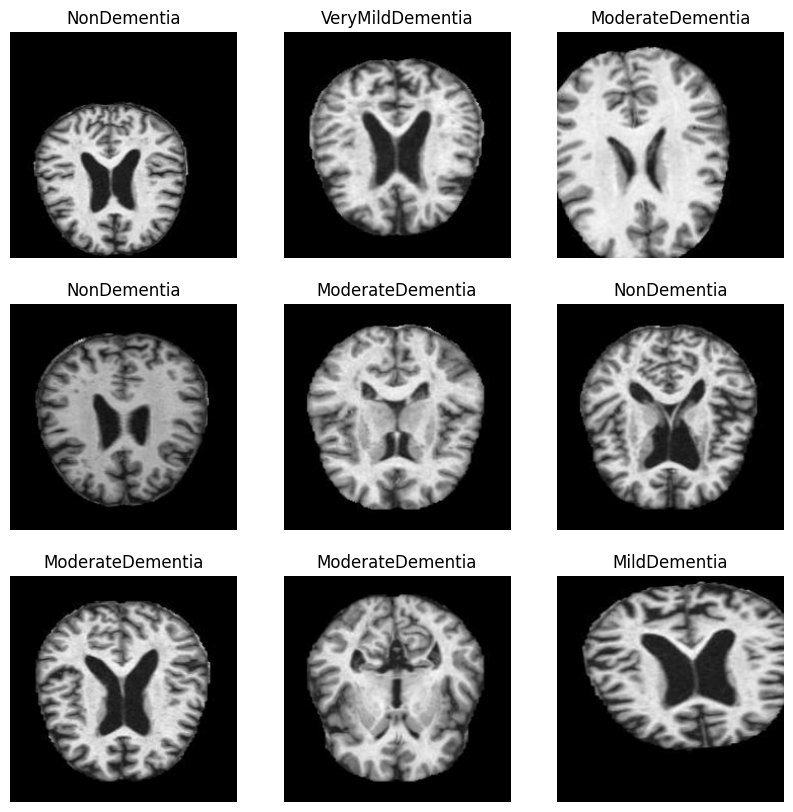

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(train_ds.class_names[labels[i]])
    plt.axis("off")

In [ ]:
def one_hot_label(image, label):
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label

train_ds = train_ds.map(one_hot_label, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(one_hot_label, num_parallel_calls=AUTOTUNE)

In [ ]:
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
# Correct class names to match directory names
class_names = ['ModerateDemented', 'NonDemented', 'VeryMildDemented', 'mildDemented']

NUM_IMAGES = []

base_path = "/kaggle/input/final-alzheimer-dataset/output/Train/"

# List directories at each level to verify
print("Base directory contents:", os.listdir(base_path))

for label in class_names:
    dir_name = base_path + label
    try:
        num_images = len([name for name in os.listdir(dir_name)])
        NUM_IMAGES.append(num_images)
        print(f"{label}: {num_images} images")
    except FileNotFoundError:
        print(f"Directory not found: {dir_name}")

print("Number of images per class:", NUM_IMAGES)


Base directory contents: ['ModerateDemented', 'NonDemented', 'VeryMildDemented', 'mildDemented']
ModerateDemented: 2400 images
NonDemented: 2400 images
VeryMildDemented: 2400 images
mildDemented: 2400 images
Number of images per class: [2400, 2400, 2400, 2400]


In [ ]:
# Define class names based on your dataset
class_names = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']

# Load the pre-trained ResNet50 model without the top layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(*IMAGE_SIZE, 3))

# Add custom layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(512, activation='relu')(x)
predictions = Dense(len(class_names), activation='softmax')(x)

# Define the complete model
model = Model(inputs=base_model.input, outputs=predictions)

# Freeze the base model layers to prevent them from being trained
for layer in base_model.layers:
    layer.trainable = False

# Print the model summary
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 26,212,740 (99.99 MB)

 Trainable params: 2,625,028 (10.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.000001), loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Define the checkpoint callback to save only the best model based on validation accuracy
checkpoint_cb = ModelCheckpoint(
    filepath='/kaggle/working/RestNet50_best_Weights.weights.h5',  # The path where the model weights will be saved
    monitor='val_accuracy',  # Metric to monitor
    save_best_only=True,  # Only save the best model
    save_weights_only=True,  # Save only weights
    mode='max',  # Mode can be 'min', 'max', or 'auto'
    verbose=2  # Display messages
)

# Define the CSVLogger callback to save training history
csv_logger = CSVLogger('training_log.csv', separator=',', append=False)


In [ ]:
# Training the model (initial phase)
history = model.fit(train_ds, validation_data=val_ds, epochs=100, callbacks=[checkpoint_cb, csv_logger])

Epoch 1/100
  1/240 ━━━━━━━━━━━━━━━━━━━━ 52:10 13s/step - accuracy: 0.1562 - loss: 1.7151

I0000 00:00:1756493571.301309     134 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.3368 - loss: 1.3708
Epoch 1: val_accuracy improved from -inf to 0.67118, saving model to /kaggle/working/RestNet50_best_Weights.weights.h5
240/240 ━━━━━━━━━━━━━━━━━━━━ 37s 99ms/step - accuracy: 0.3374 - loss: 1.3703 - val_accuracy: 0.6712 - val_loss: 1.1124
Epoch 2/100
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6723 - loss: 1.0730
Epoch 2: val_accuracy improved from 0.67118 to 0.71944, saving model to /kaggle/working/RestNet50_best_Weights.weights.h5
240/240 ━━━━━━━━━━━━━━━━━━━━ 14s 60ms/step - accuracy: 0.6724 - loss: 1.0727 - val_accuracy: 0.7194 - val_loss: 0.9413
Epoch 3/100
239/240 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7150 - loss: 0.9221
Epoch 3: val_accuracy improved from 0.71944 to 0.74931, saving model to /kaggle/working/RestNet50_best_Weights.weights.h5
240/240 ━━━━━━━━━━━━━━━━━━━━ 14s 59ms/step - accuracy: 0.7151 - loss: 0.9219 - val_accuracy: 0.7493 - val_loss: 0.8310
Epoch 4/100
239/240 ━━━━━━━━

In [ ]:
# Save the final model
model.save('/kaggle/working//RestNet50_final_model.h5')

In [ ]:
# Evaluate the model on the validation dataset
loss, accuracy = model.evaluate(val_ds)
print(f"ResNet50 Validation Loss: {loss:.4f}")
print(f"ResNet50 Validation Accuracy: {accuracy * 100:.2f}%")

90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8605 - loss: 0.3422
ResNet50 Validation Loss: 0.3513
ResNet50 Validation Accuracy: 84.97%


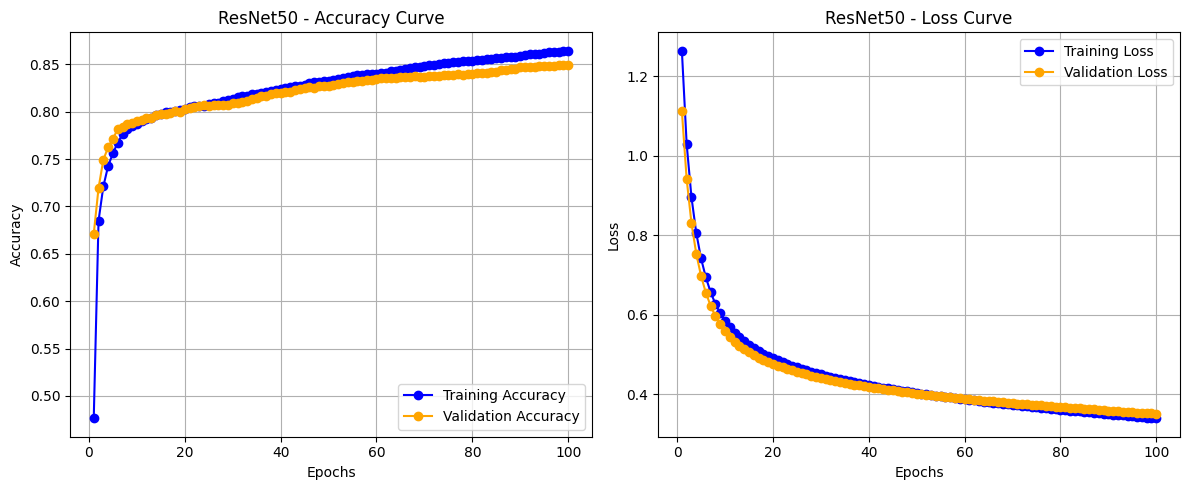

In [ ]:
# Extract accuracy and loss for the first 100 epochs from the history object
acc = history.history['accuracy'][:100]  # Slicing the first 100 epochs
val_acc = history.history['val_accuracy'][:100]
loss = history.history['loss'][:100]
val_loss = history.history['val_loss'][:100]

# Define the range of epochs for the first 100 epochs
epochs_range = range(1, 101)

# Create a side-by-side layout for accuracy and loss
plt.figure(figsize=(12, 5))  # Adjust the figure size for better layout

# Plot training and validation accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', marker='o')
plt.title('ResNet50 - Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid()

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', marker='o')
plt.title('ResNet50 - Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid()

# Adjust layout for readability
plt.tight_layout()

# Save the figure for both accuracy and loss with high resolution (DPI)
plt.savefig('/kaggle/working/model_accuracy_loss_first_100_epochs.png', dpi=300, bbox_inches='tight')

# Show the plots
plt.show()

In [ ]:
# Extract the true labels and predicted probabilities from the validation dataset
true_labels = np.concatenate([y for _, y in val_ds], axis=0)
pred_probs = model.predict(val_ds)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(true_labels, axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels, target_names=class_names))

90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step

Classification Report:
                  precision    recall  f1-score   support

     NonDemented       1.00      0.98      0.99       719
VeryMildDemented       0.79      0.80      0.79       728
    MildDemented       0.71      0.80      0.75       728
ModerateDemented       0.94      0.82      0.88       705

        accuracy                           0.85      2880
       macro avg       0.86      0.85      0.85      2880
    weighted avg       0.86      0.85      0.85      2880




Confusion Matrix:
[[706   1  10   2]
 [  0 581 134  13]
 [  1 123 579  25]
 [  0  29  95 581]]


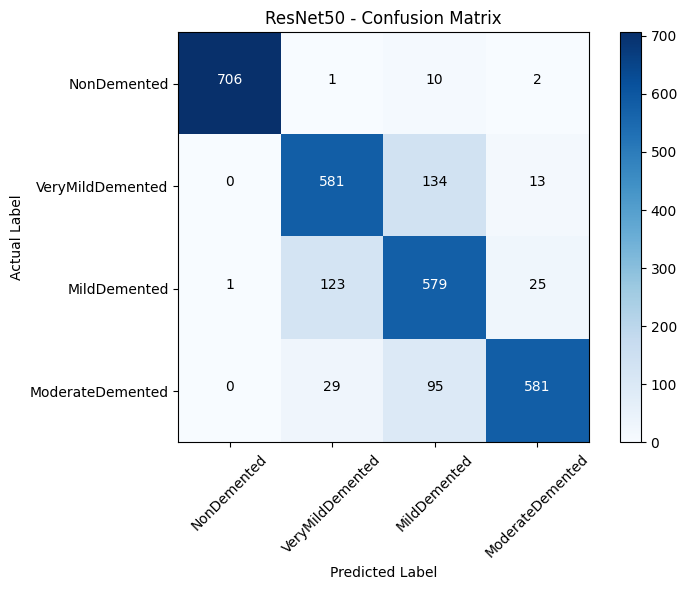

In [ ]:
# Confusion Matrix
conf_matrix = confusion_matrix(true_labels, pred_labels)

# Print Confusion Matrix
print("\nConfusion Matrix:")
print(conf_matrix)

# Plot Confusion Matrix with Only Counts
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("ResNet50 - Confusion Matrix")
plt.colorbar()

# Define tick marks and labels
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# Add integer counts to each cell
thresh = conf_matrix.max() / 2.
for i, j in np.ndindex(conf_matrix.shape):
    plt.text(j, i, f"{conf_matrix[i, j]}",
             horizontalalignment="center",
             color="white" if conf_matrix[i, j] > thresh else "black")

plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━

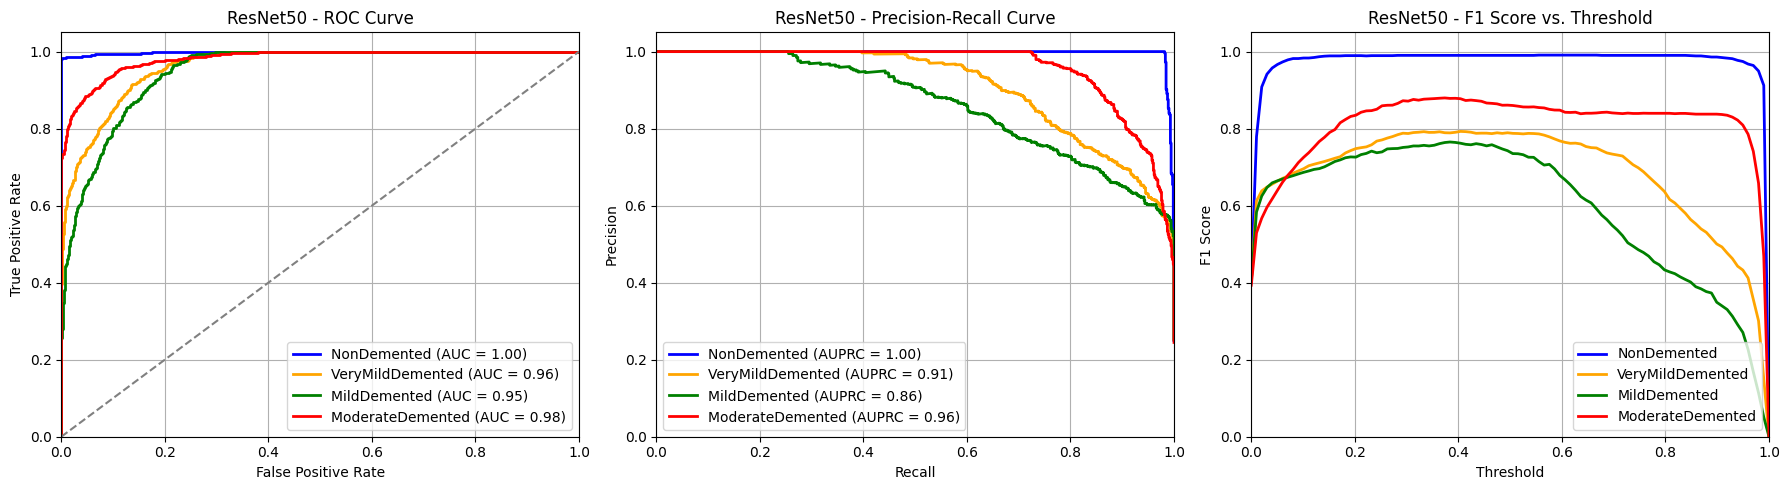


Classification Report with Specificity:
NonDemented:
  Precision: 1.00
  Recall: 0.98
  F1-Score: 0.99
  Specificity: 1.00
  Support: 719
VeryMildDemented:
  Precision: 0.79
  Recall: 0.80
  F1-Score: 0.79
  Specificity: 0.93
  Support: 728
MildDemented:
  Precision: 0.71
  Recall: 0.80
  F1-Score: 0.75
  Specificity: 0.89
  Support: 728
ModerateDemented:
  Precision: 0.94
  Recall: 0.82
  F1-Score: 0.88
  Specificity: 0.98
  Support: 705


In [ ]:
# Assuming model, val_ds, and history are already defined
# Get true labels and predicted probabilities from the validation dataset
y_true = []
y_pred_probs = []

# Iterate through the validation dataset to collect true labels and predictions
for images, labels in val_ds:
    y_true.extend(labels.numpy())  # Assuming labels are one-hot encoded
    y_pred_probs.extend(model.predict(images))  # Predicted probabilities for all classes

y_true = np.array(y_true)  # Shape: (n_samples, n_classes)
y_pred_probs = np.array(y_pred_probs)  # Shape: (n_samples, n_classes)

# Get the number of classes (4 based on the confusion matrix)
n_classes = y_true.shape[1]
class_names = ['NonDemented', 'VeryMildDemented', 'MildDemented', 'ModerateDemented']

# Initialize figure for ROC, Precision-Recall, and F1 score plots
plt.figure(figsize=(18, 5))

# Colors for different classes
colors = ['blue', 'orange', 'green', 'red']

# 1. ROC Curve (One-vs-Rest for each class)
plt.subplot(1, 3, 1)
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ResNet50 - ROC Curve')
plt.legend(loc='lower right')
plt.grid()

# 2. Precision-Recall Curve (One-vs-Rest for each class)
plt.subplot(1, 3, 2)
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(y_true[:, i], y_pred_probs[:, i])
    auprc = auc_pr(recall, precision)
    plt.plot(recall, precision, color=colors[i], lw=2, label=f'{class_names[i]} (AUPRC = {auprc:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('ResNet50 - Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid()

# 3. F1 Score vs. Threshold (One-vs-Rest for each class)
plt.subplot(1, 3, 3)
thresholds = np.linspace(0, 1, 100)
for i in range(n_classes):
    f1_scores = [f1_score(y_true[:, i], (y_pred_probs[:, i] >= t).astype(int)) for t in thresholds]
    plt.plot(thresholds, f1_scores, color=colors[i], lw=2, label=f'{class_names[i]}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('ResNet50 - F1 Score vs. Threshold')
plt.legend(loc='lower right')
plt.grid()

# Adjust layout for better readability
plt.tight_layout()

# Save the combined figure with high resolution
plt.savefig('/kaggle/working/model_roc_pr_f1_curves_multiclass.png', dpi=300, bbox_inches='tight')

# Show the plots
plt.show()

# Custom function to calculate specificity (True Negative Rate)
def specificity_score(y_true, y_pred):
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tn / (tn + fp) if (tn + fp) > 0 else 0

# Convert probabilities to class indices for classification report
y_pred = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_true, axis=1)

# Calculate specificity for each class
specificities = []
for i in range(n_classes):
    y_true_binary = (y_true_labels == i).astype(int)
    y_pred_binary = (y_pred == i).astype(int)
    specificities.append(specificity_score(y_true_binary, y_pred_binary))

# Print classification report with specificity
print("\nClassification Report with Specificity:")
report = classification_report(y_true_labels, y_pred, target_names=class_names, output_dict=True)
for i, class_name in enumerate(class_names):
    class_report = report[class_name]
    class_report['specificity'] = specificities[i]
    print(f"{class_name}:")
    print(f"  Precision: {class_report['precision']:.2f}")
    print(f"  Recall: {class_report['recall']:.2f}")
    print(f"  F1-Score: {class_report['f1-score']:.2f}")
    print(f"  Specificity: {specificities[i]:.2f}")
    print(f"  Support: {class_report['support']}")